In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sergionefedov/dubai-real-estate-sales-and-rentals-20202026")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026


In [43]:
prices = pd.read_csv('/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/area_prices_monthly.csv')
metro = pd.read_csv('/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/metro_stations.csv')
rentals = pd.read_csv('/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/rentals.csv')
sales = pd.read_csv('/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/secondary_sales.csv')

In [44]:
prices.head()

,year_month,community,zone,is_freehold,secondary_price_per_sqft_usd,secondary_price_per_m2_usd,offplan_price_per_sqft_usd,rental_price_per_sqft_annual_usd,n_listings_secondary,n_listings_offplan,n_listings_rental,cbuae_base_rate_pct,avg_mortgage_rate_pct
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,662,7126,752.0,43,26,72,111,1.5,3.0
1,2020-02,Palm Jumeirah,Palm Jumeirah,True,666,7167,728.0,43,64,78,45,1.5,3.0
2,2020-03,Palm Jumeirah,Palm Jumeirah,True,703,7564,762.0,46,144,71,99,1.5,3.0
3,2020-04,Palm Jumeirah,Palm Jumeirah,True,651,7002,727.0,42,146,69,14,0.4,1.9
4,2020-05,Palm Jumeirah,Palm Jumeirah,True,637,6852,676.0,41,147,28,83,0.4,1.9


In [8]:
sales.head()

,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,...,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,...,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,...,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,...,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,...,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,...,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


In [7]:
rentals.head()

,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451


In [9]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6384 entries, 0 to 6383
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year_month                        6384 non-null   object 
 1   community                         6384 non-null   object 
 2   zone                              6384 non-null   object 
 3   is_freehold                       6384 non-null   bool   
 4   secondary_price_per_sqft_usd      6384 non-null   int64  
 5   secondary_price_per_m2_usd        6384 non-null   int64  
 6   offplan_price_per_sqft_usd        5624 non-null   float64
 7   rental_price_per_sqft_annual_usd  6384 non-null   int64  
 8   n_listings_secondary              6384 non-null   int64  
 9   n_listings_offplan                6384 non-null   int64  
 10  n_listings_rental                 6384 non-null   int64  
 11  cbuae_base_rate_pct               6384 non-null   float64
 12  avg_mo

In [45]:
offmed = prices['offplan_price_per_sqft_usd'].median()

In [46]:
prices['offplan_price_per_sqft_usd'] = prices['offplan_price_per_sqft_usd'].fillna(offmed)

In [47]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6384 entries, 0 to 6383
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year_month                        6384 non-null   object 
 1   community                         6384 non-null   object 
 2   zone                              6384 non-null   object 
 3   is_freehold                       6384 non-null   bool   
 4   secondary_price_per_sqft_usd      6384 non-null   int64  
 5   secondary_price_per_m2_usd        6384 non-null   int64  
 6   offplan_price_per_sqft_usd        6384 non-null   float64
 7   rental_price_per_sqft_annual_usd  6384 non-null   int64  
 8   n_listings_secondary              6384 non-null   int64  
 9   n_listings_offplan                6384 non-null   int64  
 10  n_listings_rental                 6384 non-null   int64  
 11  cbuae_base_rate_pct               6384 non-null   float64
 12  avg_mo

In [48]:
prices.duplicated().value_counts()

False    6384
Name: count, dtype: int64

In [18]:
rentals.duplicated().value_counts()

False    25000
Name: count, dtype: int64

In [49]:
prices.columns

Index(['year_month', 'community', 'zone', 'is_freehold',
       'secondary_price_per_sqft_usd', 'secondary_price_per_m2_usd',
       'offplan_price_per_sqft_usd', 'rental_price_per_sqft_annual_usd',
       'n_listings_secondary', 'n_listings_offplan', 'n_listings_rental',
       'cbuae_base_rate_pct', 'avg_mortgage_rate_pct'],
      dtype='object')

In [51]:
prices = prices.drop( ['secondary_price_per_sqft_usd', 'secondary_price_per_m2_usd',
       'offplan_price_per_sqft_usd','n_listings_secondary', 'n_listings_offplan','cbuae_base_rate_pct'],axis = 1)

KeyError: "['secondary_price_per_sqft_usd', 'secondary_price_per_m2_usd', 'offplan_price_per_sqft_usd', 'n_listings_secondary', 'n_listings_offplan', 'cbuae_base_rate_pct'] not found in axis"

In [52]:
prices.head()

,year_month,community,zone,is_freehold,rental_price_per_sqft_annual_usd,n_listings_rental,avg_mortgage_rate_pct
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,43,111,3.0
1,2020-02,Palm Jumeirah,Palm Jumeirah,True,43,45,3.0
2,2020-03,Palm Jumeirah,Palm Jumeirah,True,46,99,3.0
3,2020-04,Palm Jumeirah,Palm Jumeirah,True,42,14,1.9
4,2020-05,Palm Jumeirah,Palm Jumeirah,True,41,83,1.9


In [53]:
free = pd.get_dummies(prices['is_freehold'],dtype = int,drop_first = True)

In [54]:
free.value_counts()

True
1       5624
0        760
Name: count, dtype: int64

In [55]:
prices['free'] = free

In [56]:
prices.head()

,year_month,community,zone,is_freehold,rental_price_per_sqft_annual_usd,n_listings_rental,avg_mortgage_rate_pct,free
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,43,111,3.0,1
1,2020-02,Palm Jumeirah,Palm Jumeirah,True,43,45,3.0,1
2,2020-03,Palm Jumeirah,Palm Jumeirah,True,46,99,3.0,1
3,2020-04,Palm Jumeirah,Palm Jumeirah,True,42,14,1.9,1
4,2020-05,Palm Jumeirah,Palm Jumeirah,True,41,83,1.9,1


In [57]:
prices = prices.drop('is_freehold',axis = 1)

In [58]:
prices = prices[prices['free'] == 0]

In [59]:
prices.shape

(760, 7)

In [60]:
prices.head()

,year_month,community,zone,rental_price_per_sqft_annual_usd,n_listings_rental,avg_mortgage_rate_pct,free
2280,2020-01,Al Barsha,Al Barsha,14,84,3.0,0
2281,2020-02,Al Barsha,Al Barsha,15,112,3.0,0
2282,2020-03,Al Barsha,Al Barsha,14,101,3.0,0
2283,2020-04,Al Barsha,Al Barsha,15,44,1.9,0
2284,2020-05,Al Barsha,Al Barsha,14,41,1.9,0


In [63]:
prices = prices.reset_index()

In [64]:
prices = prices.drop('index', axis = 1)

In [65]:
prices.head()

,year_month,community,zone,rental_price_per_sqft_annual_usd,n_listings_rental,avg_mortgage_rate_pct,free
0,2020-01,Al Barsha,Al Barsha,14,84,3.0,0
1,2020-02,Al Barsha,Al Barsha,15,112,3.0,0
2,2020-03,Al Barsha,Al Barsha,14,101,3.0,0
3,2020-04,Al Barsha,Al Barsha,15,44,1.9,0
4,2020-05,Al Barsha,Al Barsha,14,41,1.9,0


In [66]:
rentals.head()

,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451


In [68]:
rentals.columns

Index(['id', 'date_listed', 'community', 'zone', 'lat', 'lon',
       'property_category', 'property_type', 'bedrooms', 'area_sqft',
       'area_m2', 'view', 'furnishing', 'chiller_included', 'parking_spaces',
       'metro_station', 'metro_line', 'metro_distance_min',
       'to_burj_khalifa_km', 'contract_type', 'n_cheques', 'annual_rent_usd',
       'rent_per_sqft_usd', 'rent_per_m2_usd'],
      dtype='object')

In [69]:
prices.columns

Index(['year_month', 'community', 'zone', 'rental_price_per_sqft_annual_usd',
       'n_listings_rental', 'avg_mortgage_rate_pct', 'free'],
      dtype='object')

In [73]:
prices['year_month'] = pd.to_datetime(prices['year_month'])
prices = prices.sort_values('year_month')

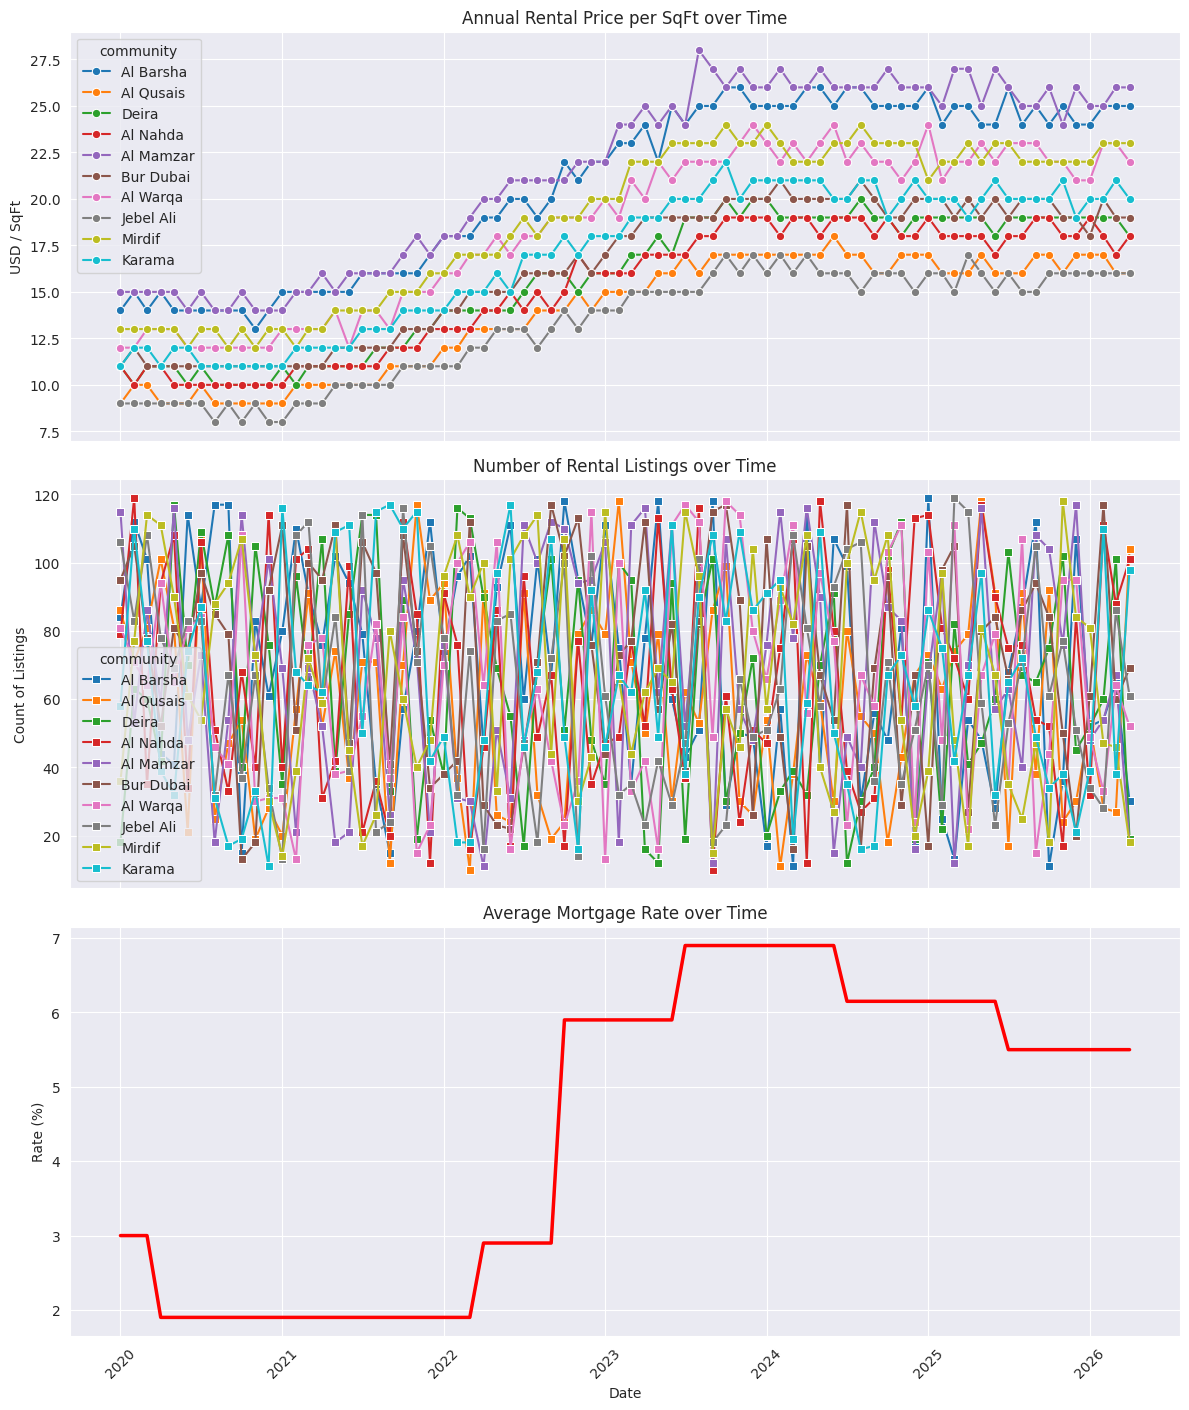

In [74]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 14), sharex=True)

# Plot 1: Rental Price Trend
sns.lineplot(
    data=prices, 
    x='year_month', 
    y='rental_price_per_sqft_annual_usd', 
    hue='community', 
    marker='o', 
    ax=axes[0]
)
axes[0].set_title('Annual Rental Price per SqFt over Time')
axes[0].set_ylabel('USD / SqFt')

# Plot 2: Market Supply Trend (Number of Listings)
sns.lineplot(
    data=prices, 
    x='year_month', 
    y='n_listings_rental', 
    hue='community', 
    marker='s', 
    ax=axes[1]
)
axes[1].set_title('Number of Rental Listings over Time')
axes[1].set_ylabel('Count of Listings')

# Plot 3: Macroeconomic Indicator (Mortgage Rate)
sns.lineplot(
    data=prices, 
    x='year_month', 
    y='avg_mortgage_rate_pct', 
    color='red', 
    linewidth=2.5, 
    ax=axes[2]
)
axes[2].set_title('Average Mortgage Rate over Time')
axes[2].set_ylabel('Rate (%)')
axes[2].set_xlabel('Date')


plt.tight_layout()
plt.xticks(rotation=45)

plt.show()


In [80]:
from statsmodels.tsa.arima.model import ARIMA

prices['year_month'] = pd.to_datetime(prices['year_month'])

mortgage_series = prices.groupby('year_month')['avg_mortgage_rate_pct'].first()

model = ARIMA(mortgage_series, order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)
print(forecast)

2026-05-01    5.5
2026-06-01    5.5
2026-07-01    5.5
2026-08-01    5.5
2026-09-01    5.5
2026-10-01    5.5
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [84]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Clean and set the time index
prices['year_month'] = pd.to_datetime(prices['year_month'])
prices = prices.sort_values('year_month')

# 2. Filter for a single community to forecast its specific supply trend
community_df = prices[prices['community'] == 'Al Barsha'].set_index('year_month')

# Resample to ensure consecutive monthly data points
supply_series = community_df['n_listings_rental'].resample('MS').first()

# 3. Fit a SARIMAX model (Handles both general trend and yearly seasonality)
# order=(p,d,q), seasonal_order=(P,D,Q,s) where s=12 for annual monthly cycles
model = SARIMAX(supply_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit(disp=False)

# 4. Forecast supply for the next 3 months
forecast = results.get_forecast(steps=3)
print(forecast.summary_frame(alpha=0.05))



n_listings_rental       mean    mean_se  mean_ci_lower  mean_ci_upper
2026-05-01         56.572281  35.153326     -12.326971     125.471533
2026-06-01         70.015812  35.124729       1.172608     138.859015
2026-07-01         51.608468  35.128254     -17.241644     120.458580


In [85]:
# Create a feature tracking the supply shift from last month
prices['listings_change_pct'] = prices.groupby('community')['n_listings_rental'].pct_change(periods=1)

In [86]:
prices

,year_month,community,zone,rental_price_per_sqft_annual_usd,n_listings_rental,avg_mortgage_rate_pct,free,listings_change_pct
0,2020-01-01,Al Barsha,Al Barsha,14,84,3.0,0,NaN
304,2020-01-01,Al Qusais,Al Qusais,9,86,3.0,0,NaN
152,2020-01-01,Deira,Deira,11,18,3.0,0,NaN
380,2020-01-01,Al Nahda,Al Nahda,11,79,3.0,0,NaN
684,2020-01-01,Al Mamzar,Al Mamzar,15,115,3.0,0,NaN
...,...,...,...,...,...,...,...,...
607,2026-04-01,Al Warqa,Al Warqa,22,52,5.5,0,-0.187500
531,2026-04-01,Mirdif,Mirdif,23,18,5.5,0,-0.608696
455,2026-04-01,Al Nahda,Al Nahda,18,101,5.5,0,0.147727
303,2026-04-01,Karama,Bur Dubai,20,98,5.5,0,1.578947
